# 4th-Grade Math Interim Assessment Analysis

**Turning classroom assessment data into instructional decisions.**

This project analyzes two interim math assessments taken by a single 4th-grade class
during the 2025–2026 school year. The goal is the one a teacher or instructional coach
actually faces: *given the assessment results, where should instructional time go next,
and which students need which kind of support?*

The data comes from a real classroom (exported from a mastery-tracking platform). **All
student names and IDs have been removed and replaced with anonymous labels (S01, S02, …)
before any analysis** — see `prepare_data.py`. No student is identifiable in this notebook.

### What this analysis covers
1. **Class overview** — performance on each interim and the distribution of scores
2. **Growth** — matched student-by-student change from Interim 1 to Interim 2
3. **Standards / skill gaps** — which Tennessee math standards are strong vs. weak
4. **Item analysis** — the specific questions that tripped the class up
5. **Tiered grouping** — sorting students into instructional groups with recommended actions

### Tools
Python · pandas · matplotlib

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

growth   = pd.read_csv('data/student_growth.csv')
standards = pd.read_csv('data/standards_long.csv')
items    = pd.read_csv('data/item_analysis.csv')

print(f"Matched students (took both interims): {len(growth)}")
growth.head()

Matched students (took both interims): 41


  anon_id  interim1_pct  interim2_pct  growth_pts
0     S01          81.0          89.0         8.0
1     S02          73.0          61.0       -12.0
2     S03          58.0          54.0        -4.0
3     S04          85.0          86.0         1.0
4     S05          69.0          43.0       -26.0

### A note on the data

Interim 1 (October) and Interim 2 (December) are **not the same test**. Interim 1 covered
five Number & Base-Ten standards. Interim 2 kept those and **added harder content**:
division (4.NBT.B.6) and the Operations & Algebraic Thinking word-problem standards
(4.OA.A.1–3). So a raw score comparison between the two is not apples-to-apples — the
growth section below is read with that context in mind, which is itself part of the
analysis.

## 2. Class Overview

          Interim 1  Interim 2
Mean %         71.3       66.3
Median %       73.0       68.0
Min %          15.0       25.0
Max %          92.0      100.0


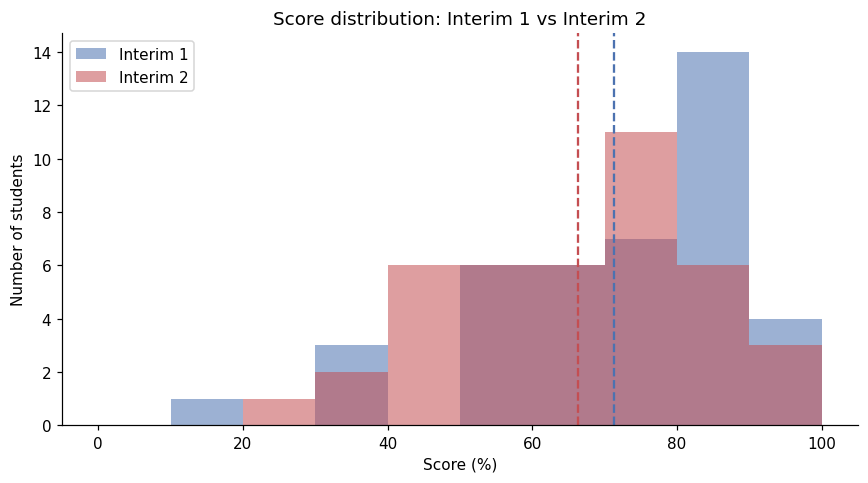

In [2]:
overview = pd.DataFrame({
    'Interim 1': [growth.interim1_pct.mean(), growth.interim1_pct.median(),
                  growth.interim1_pct.min(), growth.interim1_pct.max()],
    'Interim 2': [growth.interim2_pct.mean(), growth.interim2_pct.median(),
                  growth.interim2_pct.min(), growth.interim2_pct.max()],
}, index=['Mean %', 'Median %', 'Min %', 'Max %']).round(1)
print(overview)

fig, ax = plt.subplots(figsize=(8,4.5))
bins = range(0,101,10)
ax.hist(growth.interim1_pct, bins=bins, alpha=0.55, label='Interim 1', color='#4C72B0')
ax.hist(growth.interim2_pct, bins=bins, alpha=0.55, label='Interim 2', color='#C44E52')
ax.axvline(growth.interim1_pct.mean(), color='#4C72B0', ls='--', lw=1.5)
ax.axvline(growth.interim2_pct.mean(), color='#C44E52', ls='--', lw=1.5)
ax.set_xlabel('Score (%)'); ax.set_ylabel('Number of students')
ax.set_title('Score distribution: Interim 1 vs Interim 2')
ax.legend(); plt.tight_layout(); plt.show()

The class mean **fell about 5 points** between the two interims (71% → 66%). On its own
that looks like a decline, but Interim 2 introduced the hardest standards of the year
(multi-step word problems and division). The more useful question is not "did the average
drop" but "*which skills* are driving the drop" — which the standards analysis answers.

## 3. Growth: Matched Student Change

Improved: 13   Declined: 28   Mean change: -5.0 pts


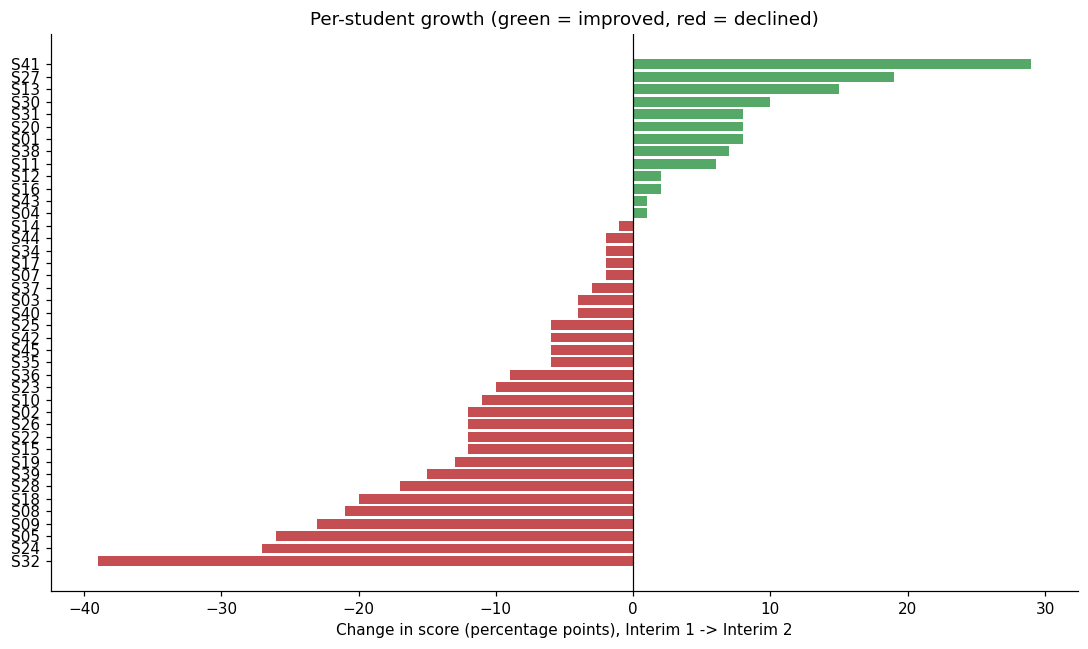

In [3]:
growth_sorted = growth.sort_values('growth_pts')
colors = ['#C44E52' if g < 0 else '#55A868' for g in growth_sorted.growth_pts]

fig, ax = plt.subplots(figsize=(10,6))
ax.barh(growth_sorted.anon_id, growth_sorted.growth_pts, color=colors)
ax.set_xlabel('Change in score (percentage points), Interim 1 -> Interim 2')
ax.set_title('Per-student growth (green = improved, red = declined)')
ax.axvline(0, color='black', lw=0.8)
plt.tight_layout(); plt.show()

print(f"Improved: {(growth.growth_pts>0).sum()}   "
      f"Declined: {(growth.growth_pts<0).sum()}   "
      f"Mean change: {growth.growth_pts.mean():+.1f} pts")

Even with the harder second assessment, **13 students improved**. The students who dropped
the most are the priority list for re-teaching — and because the drop coincides with the
new word-problem and division content, the standards view tells us whether the decline is
broad or concentrated in those new skills.

## 4. Standards / Skill-Gap Analysis

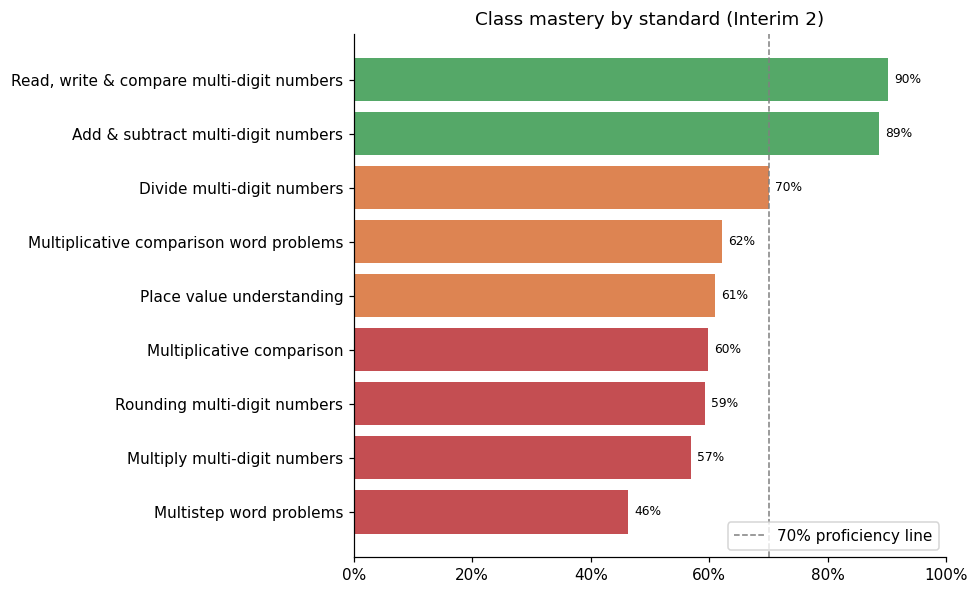

In [4]:
i2 = (standards[standards.assessment=='Interim 2']
      .groupby(['standard','skill'])
      .apply(lambda d: 100*d.correct.sum()/d['items'].sum())
      .reset_index(name='mastery'))
i2 = i2.sort_values('mastery')

fig, ax = plt.subplots(figsize=(9,5.5))
bar_colors = ['#C44E52' if m < 60 else '#DD8452' if m < 75 else '#55A868'
              for m in i2.mastery]
ax.barh(i2.skill, i2.mastery, color=bar_colors)
ax.set_xlim(0,100); ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.axvline(70, color='gray', ls='--', lw=1, label='70% proficiency line')
ax.set_title('Class mastery by standard (Interim 2)')
ax.legend(loc='lower right')
for i,(m,s) in enumerate(zip(i2.mastery,i2.standard)):
    ax.text(m+1, i, f'{m:.0f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()

**This is the actionable core of the analysis.** Two standards are strong (add/subtract and
comparing numbers, both ~89–90%). The rest cluster well below the 70% line, and the weakest
is **multi-step word problems (4.OA.A.3) at ~46%**. The decline from Interim 1 isn't general
backsliding — it's concentrated in the **new, higher-complexity standards**. That points
instruction toward word-problem strategy and multiplication fluency rather than re-teaching
everything.

## 5. Item Analysis: The Hardest Questions

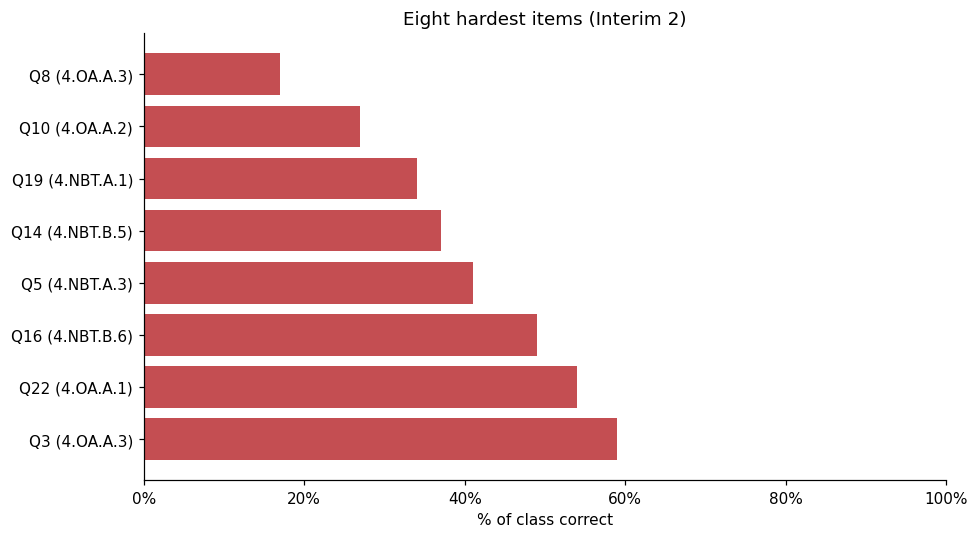

' question  standard                                   skill  class_correct_pct\n        8  4.OA.A.3                 Multistep word problems                 17\n       10  4.OA.A.2 Multiplicative comparison word problems                 27\n       19 4.NBT.A.1               Place value understanding                 34\n       14 4.NBT.B.5            Multiply multi-digit numbers                 37\n        5 4.NBT.A.3            Rounding multi-digit numbers                 41\n       16 4.NBT.B.6              Divide multi-digit numbers                 49\n       22  4.OA.A.1               Multiplicative comparison                 54\n        3  4.OA.A.3                 Multistep word problems                 59'

In [5]:
hard = items.sort_values('class_correct_pct').head(8)
fig, ax = plt.subplots(figsize=(9,5))
ax.barh([f"Q{q} ({s})" for q,s in zip(hard.question, hard.standard)],
        hard.class_correct_pct, color='#C44E52')
ax.set_xlim(0,100); ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('% of class correct')
ax.set_title('Eight hardest items (Interim 2)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()
hard[['question','standard','skill','class_correct_pct']].to_string(index=False)

Only **17%** of the class got Q8 (a multi-step word problem) correct, and **27%** got Q10
(a multiplicative-comparison word problem). When a question is missed by this much of the
class, it usually signals a shared misconception worth a whole-class mini-lesson rather than
individual remediation — these items are where a re-teach pays off most.

## 6. Tiered Grouping for Instruction

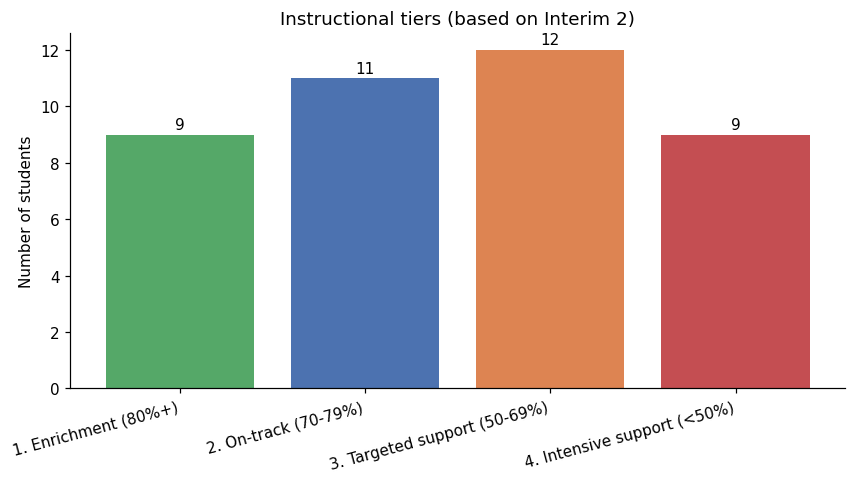

tier
1. Enrichment (80%+)             9
2. On-track (70-79%)            11
3. Targeted support (50-69%)    12
4. Intensive support (<50%)      9
Name: count, dtype: int64

In [6]:
def tier(p):
    if p >= 80: return '1. Enrichment (80%+)'
    if p >= 70: return '2. On-track (70-79%)'
    if p >= 50: return '3. Targeted support (50-69%)'
    return '4. Intensive support (<50%)'

growth['tier'] = growth.interim2_pct.apply(tier)
counts = growth.tier.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(counts.index, counts.values,
       color=['#55A868','#4C72B0','#DD8452','#C44E52'])
ax.set_ylabel('Number of students')
ax.set_title('Instructional tiers (based on Interim 2)')
plt.xticks(rotation=15, ha='right')
for i,v in enumerate(counts.values):
    ax.text(i, v+0.2, str(v), ha='center')
plt.tight_layout(); plt.show()
counts

## 7. Conclusions and Instructional Recommendations

**What the data says**
- The class splits into four clear groups: 9 students ready for enrichment, 11 on-track,
  12 needing targeted support, and 9 needing intensive support.
- The Interim 1 -> Interim 2 dip is **not broad regression** — it is concentrated in the
  new, higher-rigor standards introduced on Interim 2.
- The weakest skills are **multi-step word problems (~46%)** and **multi-digit
  multiplication (~57%)**; foundational add/subtract and number comparison are secure
  (~89–90%).

**Recommended actions**
1. **Whole-class:** a short unit on word-problem strategy (modeling, identifying operations),
   targeting 4.OA.A.3 and 4.OA.A.2 — the lowest standards and the hardest individual items.
2. **Targeted small group (the 12 "targeted support" students):** multiplication fluency and
   rounding practice (4.NBT.B.5, 4.NBT.A.3).
3. **Intensive group (the 9 below 50%):** the same skills with more scaffolding and
   one-on-one check-ins; cross-reference with the largest individual score drops.
4. **Enrichment (the 9 at 80%+):** multi-step and open-ended problems to keep them
   challenged while the teacher works with other groups.

**Honest limitations**
- The two interims are different tests, so growth is interpreted in context, not as a clean
  pre/post.
- This is one class (n≈41), so findings guide *this* classroom's instruction; they are not
  generalizable claims.
- "Mastery" here is percent-correct on a small number of items per standard (3–6), so a
  single standard's number can move a lot with one or two items.